# Corporate-bond momentum — a quantitative teardown 🔬
### The winners-minus-losers HAC *t* · a 2,000-permutation rank-shuffle placebo · the 6-12m lookback-sign sweep · the era split · an honest cost/borrow sweep · a planted-momentum synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lookback stable%3F: Not supported](https://img.shields.io/badge/Lookback_stable%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **cross-sectional momentum in bonds** (Jostova, Nikolova, Philipov & Stahel 2013) — is a rank-sort claim, distinct from time-series/own-sign trend (study 518), bond seasonality (247), and packaged carry (611/612). The job: measure the ETF-panel winners-minus-losers spread honestly, and be clear about *why* a null here is consistent with a paper that found the effect in single high-yield names.

> ⚠️ **Data note.** 11 credit + Treasury bond ETFs, daily total return (auto-adjusted close), 2007-01-03 → 2026-06-30, yfinance, cached. Dollar-neutral top/bottom-third sort, one execution `shift` (form on the month-*t* close, earn *t+1*). **Survivorship** (current-membership ETF basket) named on the Signal axis — but a *null* is not manufactured by it. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `1f2efa58efab`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bond_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.drop_partial_last_month(data.load_real())
    MP = st.to_monthly(PRICES)
    BK = st.wml_book(MP)
else:
    PRICES = MP = BK = None
print("real cache present:", HAVE_REAL, "| WML holding months:",
      (0 if BK is None else len(BK)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-01-03', 'end': '2026-06-30', 'fp': '1f2efa58efab', 'n_rows': 4903, 'n_names': 11, 'n_months': 234, 'n': 216, 'mean_pct': 1.63, 'vol_pct': 10.23, 'sharpe': 0.16, 'hac_t': 0.8, 'iid_t': 0.67, 'hit_pct': 51.4, 'wilson': (44.8, 58.0), 'max_dd_pct': -24.2, 'worst_pct': -18.88, 'turnover_pct': 50.5, 'avg_leg': 3.7, 'avg_ranked': 10.4, 'placebo_real_pct': 1.63, 'placebo_mean_pct': 0.02, 'placebo_sd_pct': 1.51, 'placebo_p': 0.152, 'placebo_n': 2000, 'lookbacks': {'6m (headline)': (1.63, 0.16, 0.8, 216), '12m': (-1.32, -0.14, -0.54, 210), '12-1': (-1.19, -0.13, -0.54, 209), '3m': (1.93, 0.2, 0.93, 219)}, 'eras': {'2007-2013 (Jostova era)': (2.51, 0.17, 0.54, 67), '2014-2026 (post-pub)': (1.23, 0.16, 0.6, 149)}, 'costs': {'5 bps + 50 borrow': (0.82, 0.08, 0.4), '10 bps + 50 borrow': (0.52, 0.05, 0.25), '20 bps + 100 borrow': (-0.59, -0.06, -0.28)}, 'break_even_bps': 26.8, 'hyg_mean_pct': 5.29, 'hyg_sharpe': 0.52, 'hyg_t': 2.47, 'long_leg_pct': 5.64, 'short_leg_pct': 4.02, 'corr_hyg': -0.1, 'syn': {0.0: (-0.2, -0.11), 0.06: (3.2, 2.51), 0.12: (11.0, 5.3), 0.2: (24.5, 8.59)}, 'syn_null_mean_t': 0.14, 'syn_null_fire': 0, 'syn_null_seeds': 20}


real cache present: True | WML holding months: 216


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | WML **+1.63%/yr**, HAC *t* = **+0.80** (plain +0.67); hit 51.4% (Wilson [44.8%, 58.0%]); rank-shuffle placebo **p = 0.152**; sign flips to -0.54 at 12m |
| **Tradability** | `MIRAGE` | break-even ≈ 27 bps one-way; net +0.52%/yr (t = +0.25) at 10 bps, negative at 20 bps; gross Sharpe 0.16, max DD -24% |
| **Lookback stable?** | `NOT SUPPORTED` | 6m *t* = +0.80 vs 12m *t* = -0.54 — sign-unstable inside the claimed window |

> 💡 In plain words: the ETF-panel momentum spread is indistinguishable from zero and not even sign-stable — consistent with Jostova et al.'s finding that bond momentum lives in the *single-name high-yield* cross-section a coarse ETF basket can't hold.

## 1 · The claim, steelmanned

Let $r^{fwd}_{i,t+1}$ be ETF $i$'s total return in month $t{+}1$ and $m_{i,t} = P_{i,t}/P_{i,t-L} - 1$ its trailing $L$-month return. The WML book longs the top-third of $\{m_{i,t}\}$ and shorts the bottom-third, equal-weight and dollar-neutral. The claims:

- **H₁ (momentum).** $E[\text{WML}_{t+1}] > 0$ with a robust *t* — recent winners keep beating recent losers next month.
- **H₂ (robust window).** The premium is stable across the 6-12 month formation the claim names (not sign-flipping).
- **H₃ (capture).** The spread survives realistic costs (one-way × NAV, short leg pays borrow).

We find **H₁ not supported** (HAC *t* = +0.80, placebo p = 0.152), **H₂ not supported** (6m +0.80 vs 12m -0.54), **H₃ moot** (no gross edge to protect). The one real premium in the panel is *owning* high-yield credit (long HYG HAC *t* = +2.47) — a level bet the WML spread is designed to strip out.

## 2 · So what? — inference design

Monthly WML returns are the unit of inference. The **planned primary** is a **Newey-West (HAC) one-sample *t*** on the monthly mean (serial-correlation robust; auto lag). We cross-check with a plain i.i.d. *t*, a Wilson interval on the positive-month rate, and a **2,000-permutation rank-shuffle placebo** — each month we keep the realised return cross-section exactly but randomly permute which ETF gets which rank, destroying the past→future link while preserving the return distribution and leg sizes. The lookback sweep (6m / 12m / 12-1 / 3m) is the pre-registered robustness rail — the claim itself names *6-12 months*, so sign-instability inside that band is decisive, not snooped.

## 3 · How we'd know — the protocol

- **Panel.** 11 credit + Treasury bond ETFs, 4,903 daily rows, 2007-01-03 → 2026-06-30; 234 month-ends, 216 WML holding months.
- **Sort.** Rank on trailing 6-month total return; long top third, short bottom third (≈ 3.7 names/leg of ≈ 10.4 ranked); dollar-neutral; form on the *t* close, earn *t+1* (one shift).
- **Signal test.** HAC *t* + plain *t* + Wilson hit rate + 2,000-perm placebo.
- **Robustness.** Lookback sweep across 6-12m (+3m, +12-1); era split 2007-2013 vs 2014-2026.
- **Execution.** Cost sweep (5/10/20 bps one-way) with the short leg paying borrow (50/100 bps/yr), and the break-even cost.
- **Control.** Synthetic total-return panel, planted-momentum knob; null must not fire (checked over 20 seeds), planted effect must be recovered.

## 4 · The teardown

### 4a · The headline spread and its placebo

HAC *t* on the monthly WML mean, plus the rank-shuffle null. In the notebook we run a lighter placebo (800 perms) and quote the canonical 2,000-perm p from `results.md`.

WML +1.63%/yr, vol 10.23%, Sharpe 0.16 (n=216)
HAC t = +0.80   plain t = +0.67
hit 51.4%  Wilson [44.8%, 58.0%]
max DD -24.2%  worst month -18.88%


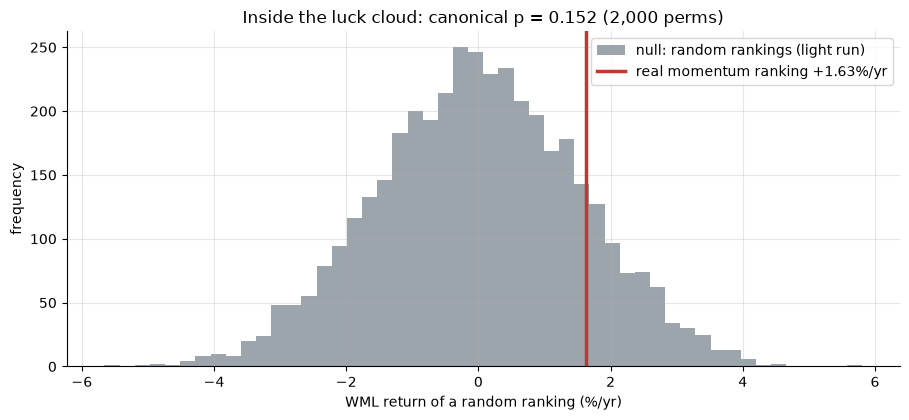

canonical placebo (results.md): real +1.63%/yr vs +0.02 (sd 1.51), p = 0.152


In [2]:
if HAVE_REAL:
    s = st.summary(BK['wml_gross'])
    print(f"WML {s['mean']*100:+.2f}%/yr, vol {s['vol']*100:.2f}%, Sharpe {s['sharpe']:.2f} (n={s['n']})")
    print(f"HAC t = {s['tstat']:+.2f}   plain t = {s['t_iid']:+.2f}")
    print(f"hit {s['hit_rate']*100:.1f}%  Wilson [{s['hit_lo']*100:.1f}%, {s['hit_hi']*100:.1f}%]")
    print(f"max DD {s['max_dd']*100:.1f}%  worst month {s['worst']*100:+.2f}%")
    pl = st.placebo_pvalue(MP, n_perm=800)
    obs = pl['real_mean_ann']*100
    draws = np.random.default_rng(795).normal(pl['placebo_mean_ann']*100, pl['placebo_sd_ann']*100, 4000)
else:
    obs = R['placebo_real_pct']
    draws = np.random.default_rng(795).normal(R['placebo_mean_pct'], R['placebo_sd_pct'], 4000)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random rankings (light run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real momentum ranking {obs:+.2f}%/yr')
ax.set_xlabel('WML return of a random ranking (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: canonical p = {R["placebo_p"]:.3f} (2,000 perms)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): real {R['placebo_real_pct']:+.2f}%/yr vs "
      f"{R['placebo_mean_pct']:+.2f} (sd {R['placebo_sd_pct']:.2f}), p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed +1.63%/yr sits well inside the null (placebo mean +0.02 ± 1.51%/yr); **p = 0.152**. HAC *t* = +0.80, hit rate a coin flip. H₁ fails on every reading.

### 4b · The killer — sign instability across the claimed lookback

The claim names a **6-12 month** formation. A real anomaly keeps its sign across that band; a data artifact doesn't.

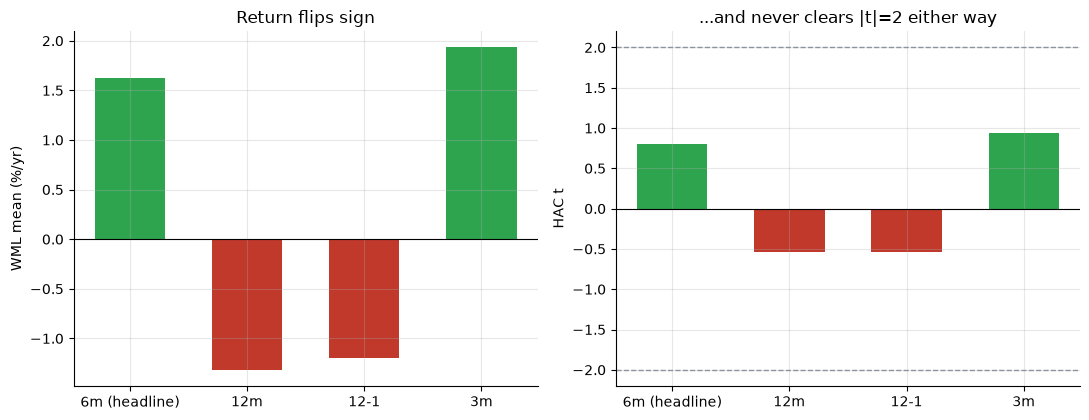

{'6m (headline)': (1.63, 0.8), '12m': (-1.32, -0.54), '12-1': (-1.19, -0.54), '3m': (1.93, 0.93)}


In [3]:
labels = list(R['lookbacks'])
if HAVE_REAL:
    rows = {}
    for lb, sk, lab in ((6,0,'6m (headline)'),(12,0,'12m'),(12,1,'12-1'),(3,0,'3m')):
        srow = st.summary(st.wml_book(MP, lookback=lb, skip=sk)['wml_gross'])
        rows[lab] = (srow['mean']*100, srow['sharpe'], srow['tstat'])
    means = [rows[k][0] for k in labels]; ts = [rows[k][2] for k in labels]
else:
    means = [R['lookbacks'][k][0] for k in labels]; ts = [R['lookbacks'][k][2] for k in labels]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(labels, means, color=[GREEN if m>0 else RED for m in means], width=.6)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('WML mean (%/yr)'); a1.set_title('Return flips sign')
a2.bar(labels, ts, color=[GREEN if t>0 else RED for t in ts], width=.6)
a2.axhline(2, ls='--', c=GREY, lw=1); a2.axhline(-2, ls='--', c=GREY, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('HAC t'); a2.set_title('...and never clears |t|=2 either way')
plt.tight_layout(); plt.show()
print({l: (round(m,2), round(t,2)) for l,m,t in zip(labels, means, ts)})

> 💡 In plain words: 6-month formation gives +1.63%/yr (*t* = +0.80); 12-month and 12-1 give -1.32 / -1.19%/yr (*t* = -0.54). The sign is *not stable* inside the exact 6-12m window the claim endorses. H₂ fails — this is the signature of no underlying effect, not of a fragile one.

### 4c · Era split — no window carries it

The Jostova sample ends ~2011; if the effect were real-but-decayed we'd see it in the early slice. We don't.

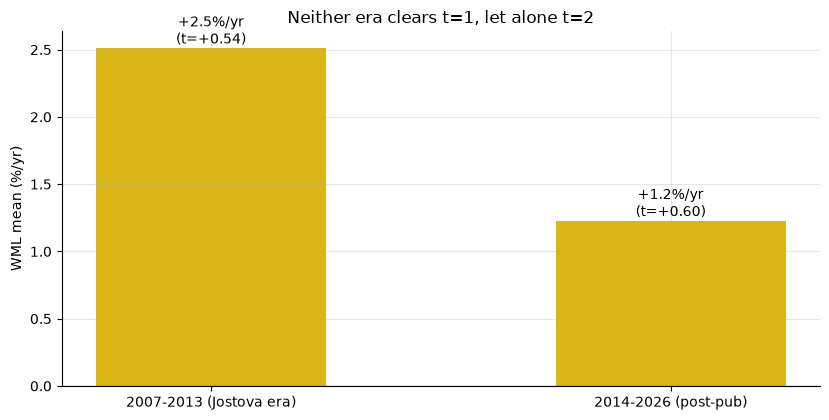

{'2007-2013 (Jostova era)': (2.51, 0.54), '2014-2026 (post-pub)': (1.23, 0.6)}


In [4]:
labels = list(R['eras'])
if HAVE_REAL:
    vals = {}
    for lo, hi, lab in (('2007-01-01','2013-12-31','2007-2013 (Jostova era)'),
                        ('2014-01-01','2026-06-30','2014-2026 (post-pub)')):
        sub = BK['wml_gross'][(BK.index>=lo)&(BK.index<=hi)]
        srow = st.summary(sub); vals[lab] = (srow['mean']*100, srow['tstat'])
    means = [vals[k][0] for k in labels]; ts = [vals[k][1] for k in labels]
else:
    means = [R['eras'][k][0] for k in labels]; ts = [R['eras'][k][2] for k in labels]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(labels, means, color=[AMBER, AMBER], width=.5)
for i,(m,t) in enumerate(zip(means, ts)): ax.annotate(f'{m:+.1f}%/yr\n(t={t:+.2f})',(i,m),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('WML mean (%/yr)')
ax.set_title('Neither era clears t=1, let alone t=2')
plt.tight_layout(); plt.show()
print({l:(round(m,2),round(t,2)) for l,m,t in zip(labels, means, ts)})

> 💡 In plain words: the in-sample-era slice (+2.51%/yr, *t* = +0.54) is no stronger than the post-publication slice (+1.23%/yr, *t* = +0.60). There is no era where the ETF spread is real — this is a level problem (wrong instrument), not a decay story.

### 4d · The timer — honest cost/borrow sweep

There's no gross edge to protect, but for completeness: one-way turnover × NAV, short leg pays borrow, and the break-even cost.

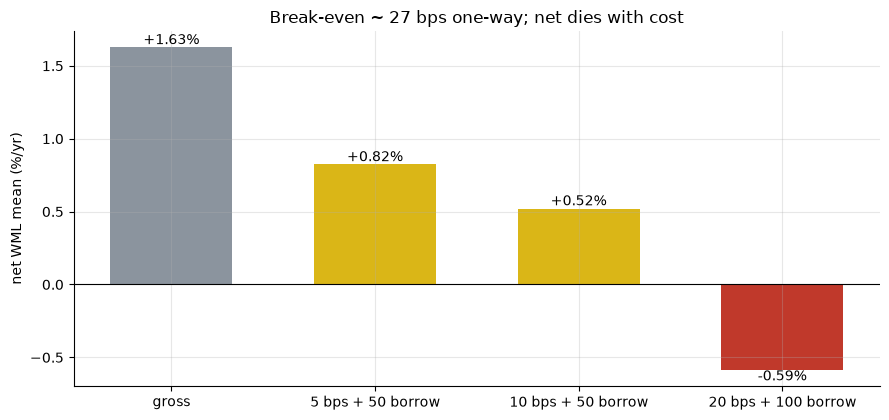

break-even ~ 26.8 bps one-way; {'5 bps + 50 borrow': (0.82, 0.4), '10 bps + 50 borrow': (0.52, 0.25), '20 bps + 100 borrow': (-0.59, -0.28)}


In [5]:
labels = list(R['costs'])
if HAVE_REAL:
    nets = {}
    for cb, bb, lab in ((5,50,'5 bps + 50 borrow'),(10,50,'10 bps + 50 borrow'),(20,100,'20 bps + 100 borrow')):
        srow = st.summary(st.wml_book(MP, cost_bps=cb, borrow_ann_bps=bb)['wml_net'])
        nets[lab] = (srow['mean']*100, srow['tstat'])
    ms = [nets[k][0] for k in labels]; ts = [nets[k][1] for k in labels]
    g = st.summary(BK['wml_gross'])['mean']*100
else:
    ms = [R['costs'][k][0] for k in labels]; ts = [R['costs'][k][2] for k in labels]
    g = R['mean_pct']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars = ['gross'] + labels; vals = [g] + ms
ax.bar(bars, vals, color=[GREY, AMBER, AMBER, RED], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net WML mean (%/yr)')
ax.set_title(f'Break-even ~ {R["break_even_bps"]:.0f} bps one-way; net dies with cost')
plt.tight_layout(); plt.show()
print(f'break-even ~ {R["break_even_bps"]:.1f} bps one-way; ' + str({l:(round(m,2),round(t,2)) for l,m,t in zip(labels, ms, ts)}))

> 💡 In plain words: gross +1.63%/yr against 50%/month turnover → break-even ≈ 27 bps one-way. Net is +0.82%/yr at 5 bps (*t* = +0.40) and -0.59%/yr at 20 bps. There was never a significant gross edge, so costs merely confirm the MIRAGE. H₃ is moot.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic total-return panel, TUNABLE planted cross-sectional momentum (seed 314). The engine must score ~0 on the null and rise with the planted strength; the null is checked over **20 seeds**.

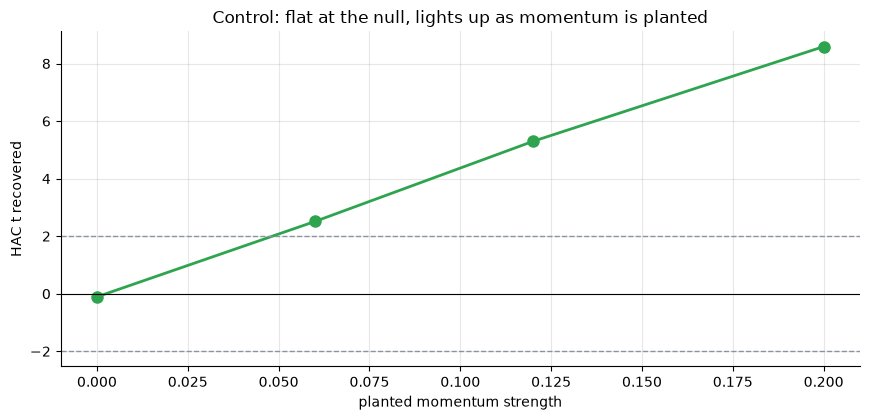

{0.0: -0.11, 0.06: 2.51, 0.12: 5.3, 0.2: 8.59}
null over 20 seeds: mean HAC t = +0.14, |t|>2 in 0% of seeds


In [6]:
sc = st.synthetic_control()
nr = st.synthetic_null_robustness()
xs = list(sc['mom_strength']); ts = list(sc['tstat'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(xs, ts, 'o-', color=GREEN, lw=2, ms=8)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('planted momentum strength'); ax.set_ylabel('HAC t recovered')
ax.set_title('Control: flat at the null, lights up as momentum is planted')
plt.tight_layout(); plt.show()
print({round(x,2): round(t,2) for x,t in zip(xs, ts)})
print(f"null over {nr['n_seeds']} seeds: mean HAC t = {nr['mean_null_t']:+.2f}, "
      f"|t|>2 in {nr['frac_abs_t_gt2']*100:.0f}% of seeds")

> 💡 In plain words: the engine scores the null at *t* = -0.11 and recovers planted momentum monotonically (*t* = +2.51 → +5.30 → +8.59); across 20 null seeds mean *t* = +0.14, |t|>2 in 0/20. The pipeline is unbiased and has ample power — so the flat real-tape *t* = +0.80 is a true reading, not a broken detector. *(Faithful-engine / power check only — never cited for the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — WML +1.63%/yr at HAC *t* = +0.80 (plain +0.67); hit 51.4% (Wilson straddles 50%); rank-shuffle placebo p = 0.152; sign flips to -0.54 at 12m; no era clears *t* = 1. No cross-sectional momentum in this bond-ETF panel.
- **Tradability `MIRAGE`** — break-even ≈ 27 bps one-way against 50%/month turnover; net +0.52%/yr (*t* = +0.25) at 10 bps, -0.59%/yr at 20 bps; gross Sharpe 0.16, max DD -24%. No residual to trade.
- **Lookback stable? `NOT SUPPORTED`** — 6m +0.80 vs 12m -0.54; sign-unstable inside the claimed window. Consistent with the effect living in the single-name high-yield cross-section a coarse ETF basket cannot hold — and with the fact that the only real premium here is *owning* credit (long HYG HAC *t* = +2.47), which the spread is built to cancel.

## 6 · Going further

- **Why the ETF wrapper kills it.** Cross-sectional momentum feeds on *dispersion to rank*. Jostova et al.'s effect is a single-name, high-yield phenomenon; a broad high-yield ETF averages that entire cross-section into one number, so the within-sleeve variation the sort needs is gone before you rank. An 11-ETF panel that is IG-and-Treasury-heavy has even less credit dispersion to work with.
- **The right next instrument** is single-name high-yield bonds (TRACE) or a much wider set of narrow credit sleeves — where the real cross-section survives — tested with the same HAC/placebo/lookback rails used here.
- **Dedup map:** [518-time-series-momentum](../../518-time-series-momentum/) (own-sign trend, not a rank sort), [247-bond-seasonality](../../247-bond-seasonality/) (a calendar signal, no cross-section), [611-mreit-carry](../../611-mreit-carry/) and [612-em-debt-carry](../../612-em-debt-carry/) (carry — a *level* signal — where the kill is the left tail, not sign-instability).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*